# Time Iteration - Consumption Saving

Pablo Winant

## General Problem

We seek to solve numerically the following consumption-saving problem
using the time-iteration algorithm.

Income is an iid normally distributed process with standard deviation
$\sigma$. Interest rate is $r\in [1,\frac{1}{\beta}[$ where
$\beta\in]0,1[$ is the discount factor.

Available income is $w_t$ and follows the law of motion:

$$w_{t+1} = e^ {\epsilon_{t+1}} +  (w_{t} - c_{t}) r$$

where $c_t \in ]0,w_t]$ is consumption chosen at date $t$ (which
includes an implicit no borrowing constraint).

## Calibration

We will use the following calibration:

$\sigma = 0.01$

$\beta = 0.96$

$r = 1.03$

1.  **Choose a structure `model` to represent the model parameters.**

In [1]:
model = (;
    σ=0.01,
    β=0.96,
    r=1.03
)

(σ = 0.01, β = 0.96, r = 1.03)

## Representing the decision function

The solution of the model is a decision rule $c(w)$.

In what follows, we will approximate it by a function defined over
$[0,w_{max}[$, pinned down by the values it takes on $N$ linearly spaced
grid points.

In our solutions algorithm, we will use the initial guess
$\varphi_0(w) = min(w, p_0+p_1(w-p_0))$.

1.  **Create a structure `approx` to represent the approximation space.
    This structure should contain the parameters, as well as a
    `points::Vector{Float64}` array coontaining the (regularly spaced)
    list of grid points.**

To start with you can take $w_{max}=5$, $N=20$, $p_0=0.95, p_1=0.03$ but
don’t hesitate to change these values later if needed.

In [33]:
approx = let 
    wmin = 0.01
    wmax = 5
    N = 15
    merge(
        (;wmin, wmax, N),
        (;
            p0 = 0.95,
            p1 = 0.03,
            points = range(start=wmin, stop=wmax; length=N)
        ),
    )
end


(wmin = 0.01, wmax = 5, N = 15, p0 = 0.95, p1 = 0.03, points = 0.01:0.35642857142857143:5.0)

1.  **Define a method `φ_0(w::Float64)::Float64` for the initial guess.
    Plot it against $w$ in the approximation space.**

In [34]:
p0 = 0.95
p1 = 0.03
φ_0(w) = min(w, p0 + p1*(w-p0))

φ_0 (generic function with 1 method)

1.  **Compute the values `c_0::{Float64}`of `φ_0()` on the grid
    `points`**

In [35]:
c_0 = φ_0.(approx.points)

15-element Vector{Float64}:
 0.01
 0.36642857142857144
 0.7228571428571429
 0.9538785714285714
 0.9645714285714285
 0.9752642857142857
 0.9859571428571428
 0.9966499999999999
 1.007342857142857
 1.0180357142857142
 1.0287285714285714
 1.0394214285714285
 1.0501142857142858
 1.0608071428571428
 1.0715

1.  **Use the `Interpolations.jl` library to define a function
    `φ(w::Float64)` defined for any `w` using piecewise *linear*
    interpolation in such a way that it takes values `c_0` on the grid
    `points`.**

In [36]:
using Interpolations

In [17]:
methods(linear_interpolation)

# 4 methods for generic function "linear_interpolation" from Interpolations:
 [1] linear_interpolation(range::AbstractRange, vs::AbstractVector; extrapolation_bc)
     @ ~/.julia/packages/Interpolations/dR5oF/src/convenience-constructors.jl:7
 [2] linear_interpolation(range::AbstractVector, vs::AbstractVector; extrapolation_bc)
     @ ~/.julia/packages/Interpolations/dR5oF/src/convenience-constructors.jl:9
 [3] linear_interpolation(ranges::NTuple{N, AbstractRange}, vs::AbstractArray{T, N}; extrapolation_bc) where {N, T}
     @ ~/.julia/packages/Interpolations/dR5oF/src/convenience-constructors.jl:22
 [4] linear_interpolation(ranges::NTuple{N, AbstractVector}, vs::AbstractArray{T, N}; extrapolation_bc) where {N, T}
     @ ~/.julia/packages/Interpolations/dR5oF/src/convenience-constructors.jl:25

In [37]:
φ(w) = linear_interpolation(approx.points, c_0)(w)

φ (generic function with 1 method)

1.  **Create a single plot with**:

- the function `φ_0()`
- the interpolated function $φ$
- its values `c_0` on the grid points

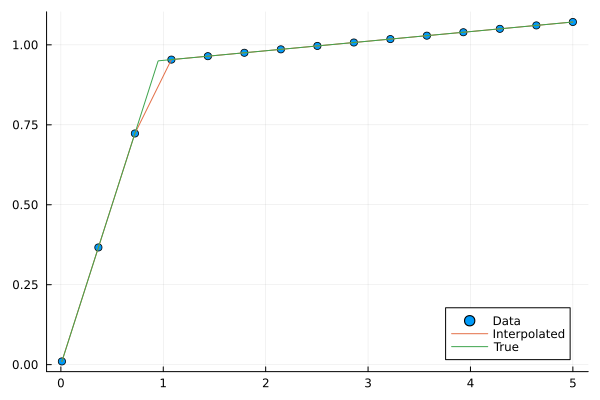

In [38]:
using Plots
fine_grid = range(;start=approx.wmin, stop=approx.wmax, length=1000)

scatter(approx.points, c_0; label="Data")
plot!(fine_grid, φ.(fine_grid), label="Interpolated")
plot!(fine_grid, φ_0.(fine_grid), label="True")

1.  **Bonus: add to the graph the function obtained using cubic spline
    interpolation. What *could* be the problem?**

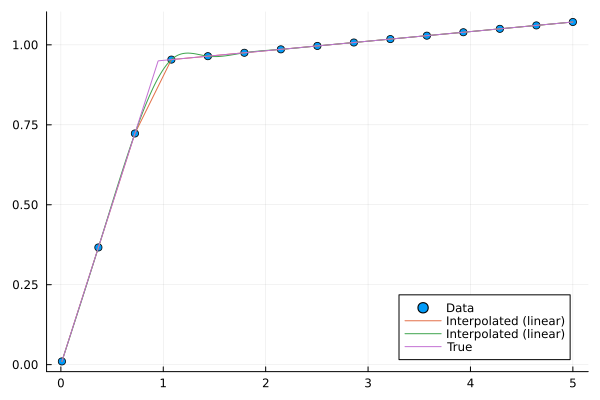

In [39]:


scatter(approx.points, c_0; label="Data")
plot!(fine_grid, φ.(fine_grid), label="Interpolated (linear)")
plot!(fine_grid, cubic_spline_interpolation(approx.points, c_0).(fine_grid), label="Interpolated (linear)")
plot!(fine_grid, φ_0.(fine_grid), label="True")

## Discretizing $\epsilon_{t+1}$

1.  **Represent the shock $\epsilon$ by two vectors $(e_1, ... e_q)$ and
    $(l_1, ..., l_q)$ with $q=10$ such that for a suitable function $g$
    we can approximate $E_{\epsilon} (g(\epsilon))$ by
    $\sum_{i=1}^q l_i e_i$ .**

(choose the method you want)

In [ ]:
# e = ...
# w = ...

1.  **Test that it works by computing
    $E_{\epsilon} \left[ \epsilon^2 \right]$.**

In [ ]:
# your code here

1.  **Redefine `approx` so as to include the discretized shock**

In [ ]:
# your code here

## Euler equation

1.  **Write down the Euler equation, paying attention to the slackness
    condition.**

It should be of the form
$$0 \leq \underbrace{E_t \left[ f(w_t, c_t, w_{t+1}, c_{t+1}, \epsilon_{t+1}) \right]}_{\Phi_t} \perp c_t \leq w_t$$

where $f$ is a function to be explicited.

In [ ]:
# your code here

1.  **Define the function
    `Phi(w::Float64,c::Float64,φ::Fun, model, approx)` which
    approximates the residuals of the euler equation given the available
    income today, the consumption choice today, the consumption
    *function* tomorrow and the model/approx structures.**

In [ ]:
# your code here

1.  **Overload `Phi` function with another method
    `Phi(w::Float64,c::Float64,φ::Fun, model, approx, slackness=true)`
    which uses the Fisher-Burmeister transform to incorporate the credit
    constraint.**

In [ ]:
# your code here

1.  **Plot the optization residuals (i.e. values of $\Phi_t$)
    corresponding to the initial guess function with and without the
    complementarity constraints.**

In [ ]:
# your code here

## Time Iteration

1.  **(prep): Assuming the initial guess $φ_0()$ is the decision rule
    followed tomorrow, determine, for a given value `w` in the
    state-space, the optimal consumption choice made today. This can be
    achieved by feeding the appropriate function into the right
    nonlinear root-finder.**

In [ ]:
# your code here

1.  **(prep): Find the vector of all the optimal consumption choices on
    the grid today, given the decision rule tomorrow.**

In [ ]:
# your code here

1.  **Plot the optimization residuals (i.e. values of $\Phi_t$) for the
    initial guess function**

In [ ]:
# your code here

1.  **Write down the time-iteration algorithm.**

You can use the course as reference and/or repeat the recurrence steps
below:

- given an initial guess for the consumption vector `c0`
- create a function defined `φ` on `[0,wmax]` which interpolates `c0` on
  the grid
- for each grid point `w` in the grid, solve the system
  `u->Phi(w,u,φ, model, approx, slackness=true)`
  - store the result as a vector `c1`
- check whether `c1` is close to `c0`
  - yes: check the system is indeed solved and return
  - no: start again with `c1` as `c0`

In [ ]:
# here is a placeholder implementation to help you structure your program.
#  feel free to modify or discard


"""
φ: Float64->Float64 Initial guess for the consumption function
model: parameters representing the model
approx: parameters defining the approximation and solution method
K: max number of iterations
... other parameters for you to choose
"""
function time_iteration(φ0, model, approx; K=200, ... )

    # ...

    # convert initial function φ0 into a consumption vector by evaluating φ on the grid
    # c0 = ... :: Vector{Float64}

    for k=1:K

        # convert consumption vector c0 into a function φ
        # φ = ...

        # solve for the optimal consumption for all grid points
        # ...
        # c1  :: Vector{Float64}

        # check distance between c0 and c1

        # η = ...

        # if distance is small return function `varphi`

    end




end

1.  **Check that the value returned by `time_iteration` is actually a
    solution to the system. How fast is the convergence? Graphical
    representation.**

In [ ]:
# your code here

## Bonuses

1.  **(easy): perform some sensitivity analysis on the model to explain
    the effect of the main parameters**

In [ ]:
# your code here

1.  **(medium): Give the solution to the above problem, simulate the law
    of motion for the available income. Find a way to plot the
    distriution of that income over a long period of time.**

2.  **(hard): Propose and implement some ideas to speed up the solution
    process.**

One promising avenue consists in solving for all consumption values at
all grid points as one single system of equation after recognizing that
the jacobian of this particular system has a specific structure.